In [2]:
import os
os.environ.pop("TF_USE_LEGACY_KERAS", None)


import librosa
%matplotlib inline
import matplotlib.pyplot as plt
import librosa.display
from IPython.display import Audio
import numpy as np
import tensorflow as tf
from matplotlib.pyplot import specgram
import pandas as pd
from sklearn.metrics import confusion_matrix
import IPython.display as ipd
import sys

data = pd.read_csv('../../data/featureRavdess.csv')

In [3]:
import numpy as np
import random

np.random.seed(42)
random.seed(42)

In [4]:
data

,0,1,2,3,4,5,6,7,8,9,...,186,187,188,189,190,191,192,0.1,0.2,speaker
0,-673.301697,69.508095,-3.494582,18.998575,5.041687,4.626438,-7.605268,-0.057042,-16.231766,-0.299419,...,31.995356,-0.051473,0.025316,-0.044013,-0.079353,0.022513,0.010037,1,1,1
1,-663.297852,67.747589,-6.961255,22.244839,5.313937,2.970508,-6.046401,-3.327282,-17.383774,0.806942,...,31.223174,-0.079423,0.034342,-0.070702,-0.074578,0.025509,-0.001626,1,1,1
2,-664.776184,70.703842,-4.903909,18.797665,1.573513,4.084437,-6.752044,-3.895945,-15.839313,-2.361090,...,31.753796,-0.024101,-0.010724,-0.007700,0.022802,-0.000364,0.032532,1,1,1
3,-660.674133,69.261803,-1.020717,19.743364,3.635317,6.417199,-5.448439,-4.090719,-15.130262,-1.551855,...,30.522612,-0.065819,0.008619,0.004848,-0.030447,-0.000754,0.014753,1,1,1
4,-699.495178,76.727394,-1.602398,21.554548,4.587931,6.054961,-8.122147,-1.003357,-15.158166,-2.688365,...,31.293542,-0.070505,0.011104,0.031151,-0.115693,0.024391,0.003346,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,-558.443298,34.201637,-25.876736,3.420890,-22.962826,-6.289969,-22.845768,-13.475706,-11.609130,-4.602691,...,31.661293,-0.020466,0.014107,0.020899,0.050697,-0.005623,0.022015,0,8,24
1436,-509.914642,49.378990,-22.979485,-0.832579,-23.050257,-10.238819,-17.452888,-8.696088,-14.158811,0.367432,...,31.846921,-0.040751,0.017479,0.014917,0.015533,0.016873,-0.000375,0,8,24
1437,-517.733276,40.459633,-27.217442,2.902560,-22.611633,-14.189220,-19.589163,-8.899709,-12.807209,3.745601,...,31.628901,-0.032364,0.032572,-0.050994,0.009171,0.007204,0.013219,0,8,24
1438,-463.998352,35.496925,-14.260783,9.399699,-19.878208,0.799514,-18.052525,-4.351163,-7.299998,0.214021,...,31.137002,-0.045889,0.027680,-0.042989,-0.060098,0.005997,-0.009220,0,8,24


In [5]:
import joblib

# Load the saved scaler
scaler = joblib.load("../scaler.pkl")

# Load the saved model
gender_model = tf.keras.models.load_model("../gender_classification_model.h5")

W0000 00:00:1764848961.605692 4156672 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [6]:
X_gender = data.iloc[:, :193].values
X_scaled = scaler.transform(X_gender)
gender_predictions = gender_model.predict(X_scaled)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 548us/step


In [7]:
print(gender_predictions)

[[7.7384239e-04]
 [7.8950549e-04]
 [1.0120951e-03]
 ...
 [9.9847502e-01]
 [9.9787855e-01]
 [9.9846315e-01]]


In [8]:
male_rows = gender_predictions.flatten() < 0.5  # 0 for Male, 1 for Female

df = data[male_rows]

print(f"Filtered dataset contains {df.shape[0]} male samples.")

Filtered dataset contains 719 male samples.


In [9]:
df.shape

(719, 196)

In [10]:
df

,0,1,2,3,4,5,6,7,8,9,...,186,187,188,189,190,191,192,0.1,0.2,speaker
0,-673.301697,69.508095,-3.494582,18.998575,5.041687,4.626438,-7.605268,-0.057042,-16.231766,-0.299419,...,31.995356,-0.051473,0.025316,-0.044013,-0.079353,0.022513,0.010037,1,1,1
1,-663.297852,67.747589,-6.961255,22.244839,5.313937,2.970508,-6.046401,-3.327282,-17.383774,0.806942,...,31.223174,-0.079423,0.034342,-0.070702,-0.074578,0.025509,-0.001626,1,1,1
2,-664.776184,70.703842,-4.903909,18.797665,1.573513,4.084437,-6.752044,-3.895945,-15.839313,-2.361090,...,31.753796,-0.024101,-0.010724,-0.007700,0.022802,-0.000364,0.032532,1,1,1
3,-660.674133,69.261803,-1.020717,19.743364,3.635317,6.417199,-5.448439,-4.090719,-15.130262,-1.551855,...,30.522612,-0.065819,0.008619,0.004848,-0.030447,-0.000754,0.014753,1,1,1
4,-699.495178,76.727394,-1.602398,21.554548,4.587931,6.054961,-8.122147,-1.003357,-15.158166,-2.688365,...,31.293542,-0.070505,0.011104,0.031151,-0.115693,0.024391,0.003346,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1375,-518.176025,54.336693,-16.867956,2.470917,-4.073838,-2.748888,-13.374091,-6.024971,-16.421869,-2.043707,...,31.550327,-0.011495,0.014177,-0.008497,-0.027965,-0.001463,0.007953,1,8,23
1376,-502.163391,49.330410,-16.674372,6.953362,-1.735307,-1.708595,-17.710266,-5.345790,-14.760635,-1.683560,...,31.989208,-0.043424,0.013255,-0.030656,0.050061,0.003688,0.007049,1,8,23
1377,-499.994263,50.926987,-19.440176,3.803090,-7.180909,-2.145453,-16.375141,-6.704348,-15.546900,-1.911119,...,32.237853,-0.059843,0.048440,-0.045319,0.020689,0.010588,0.016066,1,8,23
1378,-481.682251,41.021809,-19.435980,-0.163736,-10.369910,-2.922106,-15.791293,-7.187538,-15.690004,-3.325412,...,31.312768,-0.032609,0.030134,-0.100309,0.004273,-0.013313,-0.004990,1,8,23


In [11]:
data.iloc[:,-3] == 0

0       False
1       False
2       False
3       False
4       False
        ...  
1435     True
1436     True
1437     True
1438     True
1439     True
Name: 0.1, Length: 1440, dtype: bool

In [12]:
X_speaker = df.iloc[:, -1].copy()
X = df.iloc[:, :-3].copy()
y = df.iloc[:,-2].copy()

In [13]:
X

,0,1,2,3,4,5,6,7,8,9,...,183,184,185,186,187,188,189,190,191,192
0,-673.301697,69.508095,-3.494582,18.998575,5.041687,4.626438,-7.605268,-0.057042,-16.231766,-0.299419,...,14.502933,15.547618,17.645388,31.995356,-0.051473,0.025316,-0.044013,-0.079353,0.022513,0.010037
1,-663.297852,67.747589,-6.961255,22.244839,5.313937,2.970508,-6.046401,-3.327282,-17.383774,0.806942,...,15.213718,15.513745,17.582760,31.223174,-0.079423,0.034342,-0.070702,-0.074578,0.025509,-0.001626
2,-664.776184,70.703842,-4.903909,18.797665,1.573513,4.084437,-6.752044,-3.895945,-15.839313,-2.361090,...,14.972030,15.697508,17.437520,31.753796,-0.024101,-0.010724,-0.007700,0.022802,-0.000364,0.032532
3,-660.674133,69.261803,-1.020717,19.743364,3.635317,6.417199,-5.448439,-4.090719,-15.130262,-1.551855,...,15.242136,15.597314,16.492804,30.522612,-0.065819,0.008619,0.004848,-0.030447,-0.000754,0.014753
4,-699.495178,76.727394,-1.602398,21.554548,4.587931,6.054961,-8.122147,-1.003357,-15.158166,-2.688365,...,14.636722,16.023571,17.020093,31.293542,-0.070505,0.011104,0.031151,-0.115693,0.024391,0.003346
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1375,-518.176025,54.336693,-16.867956,2.470917,-4.073838,-2.748888,-13.374091,-6.024971,-16.421869,-2.043707,...,15.563899,16.786573,17.289161,31.550327,-0.011495,0.014177,-0.008497,-0.027965,-0.001463,0.007953
1376,-502.163391,49.330410,-16.674372,6.953362,-1.735307,-1.708595,-17.710266,-5.345790,-14.760635,-1.683560,...,15.518351,17.003934,17.874535,31.989208,-0.043424,0.013255,-0.030656,0.050061,0.003688,0.007049
1377,-499.994263,50.926987,-19.440176,3.803090,-7.180909,-2.145453,-16.375141,-6.704348,-15.546900,-1.911119,...,15.092518,16.634495,17.128656,32.237853,-0.059843,0.048440,-0.045319,0.020689,0.010588,0.016066
1378,-481.682251,41.021809,-19.435980,-0.163736,-10.369910,-2.922106,-15.791293,-7.187538,-15.690004,-3.325412,...,15.157907,16.104991,16.717183,31.312768,-0.032609,0.030134,-0.100309,0.004273,-0.013313,-0.004990


In [14]:
y

0       1
1       1
2       1
3       1
4       2
       ..
1375    8
1376    8
1377    8
1378    8
1379    8
Name: 0.2, Length: 719, dtype: int64

In [15]:
X_speaker

0        1
1        1
2        1
3        1
4        1
        ..
1375    23
1376    23
1377    23
1378    23
1379    23
Name: speaker, Length: 719, dtype: int64

In [16]:
X.shape, y.shape

((719, 193), (719,))

In [17]:
from sklearn.utils import shuffle

X, y, X_speaker = shuffle(X, y, X_speaker, random_state=42)

In [18]:
X

,0,1,2,3,4,5,6,7,8,9,...,183,184,185,186,187,188,189,190,191,192
240,-691.452515,82.156662,3.882375,20.036530,8.277701,2.692780,-3.566173,-1.029916,-4.295271,3.589765,...,15.651561,17.276828,16.533962,31.378136,-0.038085,0.044314,-0.048185,0.010280,0.010960,0.028039
284,-708.608093,66.181213,6.354491,25.112740,0.583152,3.341432,-3.133984,2.310285,-2.769953,6.368120,...,15.668430,15.694806,16.773541,31.399500,-0.035361,-0.015063,-0.005487,-0.036799,0.016123,0.006055
39,-590.983276,74.518639,-9.625761,22.812243,2.404797,4.461318,-9.366790,-8.053039,-16.515903,2.641336,...,15.891860,16.726666,18.814396,32.223629,-0.015185,0.011484,0.134152,0.024999,0.003172,0.023705
1091,-681.945312,78.568947,16.016911,33.139301,9.768853,17.960642,-7.706484,0.865045,-14.381108,4.019069,...,18.316176,17.988523,17.983600,34.090939,-0.006495,0.020611,-0.083216,0.052248,-0.003992,0.017558
379,-429.855042,58.556293,-17.621305,13.152417,3.173928,-6.004189,-23.124149,1.841852,-13.718226,3.929267,...,17.259158,18.998492,20.257584,33.922676,-0.060652,0.003370,-0.074988,0.026420,0.035579,0.014364
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131,-503.989868,68.907585,-9.939764,14.944476,-2.818100,6.875752,-26.140736,1.054880,-5.804341,-4.376976,...,16.759984,18.640375,19.054267,32.058884,0.026932,-0.021074,0.026702,-0.029949,0.021343,-0.001228
166,-573.106812,56.762455,-2.930424,20.731886,-2.298028,4.026749,-19.395811,1.150211,-10.176166,0.917685,...,14.974672,16.329427,16.116918,31.336124,-0.024688,-0.019084,-0.034166,-0.040140,0.013771,-0.000854
510,-563.606079,70.182686,-14.853501,19.245783,15.801292,1.466610,-5.570126,-3.481671,-16.712420,2.720659,...,16.961951,17.358991,18.009310,33.101683,-0.018980,0.012866,0.003344,-0.025613,0.006480,-0.005541
855,-573.245605,80.446121,-12.591578,18.710548,11.635873,1.314883,-6.154487,3.073936,-10.015546,1.910821,...,15.516219,16.650834,17.991156,31.533914,-0.018724,0.019571,-0.084000,-0.056433,0.011422,-0.012925


In [19]:
X_speaker

240      5
284      5
39       1
1091    19
379      7
        ..
131      3
166      3
510      9
855     15
162      3
Name: speaker, Length: 719, dtype: int64

In [20]:
from keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
lb = LabelEncoder()
y1 = to_categorical(lb.fit_transform(y))

In [21]:
y1

array([[1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 1., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.]], shape=(719, 8))

In [22]:
X.shape, y1.shape

((719, 193), (719, 8))

In [23]:
X2_speaker = X_speaker.copy().to_numpy()
X2=X.copy().to_numpy()
y2=y.copy().to_numpy()

In [24]:
X2.shape, X2_speaker.shape, y2.shape

((719, 193), (719,), (719,))

In [25]:
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from matplotlib.pyplot import specgram
import keras

from keras.preprocessing import sequence
from keras.models import Sequential
from keras.layers import Dense, Embedding, Activation
from keras.layers import LSTM

from keras.utils import to_categorical
from keras.layers import Input, Flatten, Dropout#, Activation
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from keras.models import Model
from keras.callbacks import ModelCheckpoint
from sklearn.metrics import confusion_matrix
from keras.layers import BatchNormalization

def model1(input_shape1):
    model = Sequential()

    model.add(Conv1D(256, 5,padding='same',
                     input_shape=(input_shape1,1)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))


    model.add(Conv1D(256, 5,padding='same'))
    model.add(Activation('relu'))
    model.add(Dropout(0.1))

    model.add(BatchNormalization())

    model.add(MaxPooling1D(pool_size=(8)))
    model.add(Conv1D(256, 5,padding='same',))

    model.add(Activation('relu'))

    model.add(Conv1D(128, 5,padding='same',))
    model.add(Activation('relu'))
    model.add(Conv1D(128, 5,padding='same',))
    model.add(BatchNormalization())

    model.add(Activation('relu'))
    model.add(Dropout(0.2))

    #model.add(Conv1D(128, 5,padding='same',))
    #model.add(Activation('relu'))

    model.add(Flatten())
    model.add(Dropout(0.2))
    model.add(Dense(8))
    model.add(BatchNormalization())
    model.add(Activation('softmax'))

    #model.summary()
    return model

In [26]:
import random, numpy as np
from keras import optimizers
kfold=5
def create_index(kfold, size):
    a = []
    for i in range(size):
        a.append(i)
    random.shuffle(a)
    arr = np.array(a)
    return arr.reshape(kfold, size//kfold)

In [27]:
X3=pd.DataFrame(X2)
X3

,0,1,2,3,4,5,6,7,8,9,...,183,184,185,186,187,188,189,190,191,192
0,-691.452515,82.156662,3.882375,20.036530,8.277701,2.692780,-3.566173,-1.029916,-4.295271,3.589765,...,15.651561,17.276828,16.533962,31.378136,-0.038085,0.044314,-0.048185,0.010280,0.010960,0.028039
1,-708.608093,66.181213,6.354491,25.112740,0.583152,3.341432,-3.133984,2.310285,-2.769953,6.368120,...,15.668430,15.694806,16.773541,31.399500,-0.035361,-0.015063,-0.005487,-0.036799,0.016123,0.006055
2,-590.983276,74.518639,-9.625761,22.812243,2.404797,4.461318,-9.366790,-8.053039,-16.515903,2.641336,...,15.891860,16.726666,18.814396,32.223629,-0.015185,0.011484,0.134152,0.024999,0.003172,0.023705
3,-681.945312,78.568947,16.016911,33.139301,9.768853,17.960642,-7.706484,0.865045,-14.381108,4.019069,...,18.316176,17.988523,17.983600,34.090939,-0.006495,0.020611,-0.083216,0.052248,-0.003992,0.017558
4,-429.855042,58.556293,-17.621305,13.152417,3.173928,-6.004189,-23.124149,1.841852,-13.718226,3.929267,...,17.259158,18.998492,20.257584,33.922676,-0.060652,0.003370,-0.074988,0.026420,0.035579,0.014364
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
714,-503.989868,68.907585,-9.939764,14.944476,-2.818100,6.875752,-26.140736,1.054880,-5.804341,-4.376976,...,16.759984,18.640375,19.054267,32.058884,0.026932,-0.021074,0.026702,-0.029949,0.021343,-0.001228
715,-573.106812,56.762455,-2.930424,20.731886,-2.298028,4.026749,-19.395811,1.150211,-10.176166,0.917685,...,14.974672,16.329427,16.116918,31.336124,-0.024688,-0.019084,-0.034166,-0.040140,0.013771,-0.000854
716,-563.606079,70.182686,-14.853501,19.245783,15.801292,1.466610,-5.570126,-3.481671,-16.712420,2.720659,...,16.961951,17.358991,18.009310,33.101683,-0.018980,0.012866,0.003344,-0.025613,0.006480,-0.005541
717,-573.245605,80.446121,-12.591578,18.710548,11.635873,1.314883,-6.154487,3.073936,-10.015546,1.910821,...,15.516219,16.650834,17.991156,31.533914,-0.018724,0.019571,-0.084000,-0.056433,0.011422,-0.012925


In [28]:
X3_speaker = pd.DataFrame(X2_speaker)
X3_speaker

,0
0,5
1,5
2,1
3,19
4,7
...,...
714,3
715,3
716,9
717,15


In [29]:
speakers = X_speaker.unique()
speakers

array([ 5,  1, 19,  7,  3, 17, 23, 11, 15, 21, 13,  9])

In [30]:
X3_col = X3_speaker.rename(columns={0: 'speaker'})
X3_col

,speaker
0,5
1,5
2,1
3,19
4,7
...,...
714,3
715,3
716,9
717,15


In [31]:
X_combined = pd.concat([X3, X3_col], axis=1)
X_combined

,0,1,2,3,4,5,6,7,8,9,...,184,185,186,187,188,189,190,191,192,speaker
0,-691.452515,82.156662,3.882375,20.036530,8.277701,2.692780,-3.566173,-1.029916,-4.295271,3.589765,...,17.276828,16.533962,31.378136,-0.038085,0.044314,-0.048185,0.010280,0.010960,0.028039,5
1,-708.608093,66.181213,6.354491,25.112740,0.583152,3.341432,-3.133984,2.310285,-2.769953,6.368120,...,15.694806,16.773541,31.399500,-0.035361,-0.015063,-0.005487,-0.036799,0.016123,0.006055,5
2,-590.983276,74.518639,-9.625761,22.812243,2.404797,4.461318,-9.366790,-8.053039,-16.515903,2.641336,...,16.726666,18.814396,32.223629,-0.015185,0.011484,0.134152,0.024999,0.003172,0.023705,1
3,-681.945312,78.568947,16.016911,33.139301,9.768853,17.960642,-7.706484,0.865045,-14.381108,4.019069,...,17.988523,17.983600,34.090939,-0.006495,0.020611,-0.083216,0.052248,-0.003992,0.017558,19
4,-429.855042,58.556293,-17.621305,13.152417,3.173928,-6.004189,-23.124149,1.841852,-13.718226,3.929267,...,18.998492,20.257584,33.922676,-0.060652,0.003370,-0.074988,0.026420,0.035579,0.014364,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
714,-503.989868,68.907585,-9.939764,14.944476,-2.818100,6.875752,-26.140736,1.054880,-5.804341,-4.376976,...,18.640375,19.054267,32.058884,0.026932,-0.021074,0.026702,-0.029949,0.021343,-0.001228,3
715,-573.106812,56.762455,-2.930424,20.731886,-2.298028,4.026749,-19.395811,1.150211,-10.176166,0.917685,...,16.329427,16.116918,31.336124,-0.024688,-0.019084,-0.034166,-0.040140,0.013771,-0.000854,3
716,-563.606079,70.182686,-14.853501,19.245783,15.801292,1.466610,-5.570126,-3.481671,-16.712420,2.720659,...,17.358991,18.009310,33.101683,-0.018980,0.012866,0.003344,-0.025613,0.006480,-0.005541,9
717,-573.245605,80.446121,-12.591578,18.710548,11.635873,1.314883,-6.154487,3.073936,-10.015546,1.910821,...,16.650834,17.991156,31.533914,-0.018724,0.019571,-0.084000,-0.056433,0.011422,-0.012925,15


In [32]:
# Get random 5 speakers

speaker_counts = X_combined['speaker'].value_counts()
total_speakers = speaker_counts.head(12).index.to_numpy()
selected_speakers = np.random.choice(total_speakers, size=5, replace=False)

print("Selected speakers:", selected_speakers)

Selected speakers: [ 9 21  5 13 17]


In [33]:
def fisher_score_manual(X, y):
    n_samples, n_features = X.shape
    classes = np.unique(y)
    score = np.zeros(n_features)
    for i in range(n_features):
        numerator = 0
        denominator = 0
        overall_mean = np.mean(X[:, i])
        for c in classes:
            Xc = X[y==c, i]
            nc = len(Xc)
            mean_c = np.mean(Xc)
            var_c = np.var(Xc)
            numerator += nc * (mean_c - overall_mean)**2
            denominator += nc * var_c
        score[i] = numerator / denominator if denominator != 0 else 0
    return score

In [34]:
from skfeature.function.similarity_based import fisher_score
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler

hist=[]
scores=[]
totalsize=715
num_fea=125
a=create_index(kfold,totalsize)

top_features_per_fold = []
importance_per_fold = []

for i in range (kfold):
    model_name = 'Model_'+str(i)
    savedir='ravdess_speaker_male'
    model_path = os.path.join(savedir, (model_name+'.h5'))

    # Choose one test speaker from selected_speakers
    test_speaker = selected_speakers[i]

    # Use only speakers not in selected_speakers as training
    train_speakers = np.setdiff1d(speakers, [test_speaker])

    print(f"\n===== Fold {i} =====")
    print("Test speaker:", test_speaker)
    print("Train speakers:", train_speakers)

    # Get the indices for test and train
    train_indices = X_combined[X_combined['speaker'].isin(train_speakers)].index
    test_indices = X_combined[X_combined['speaker'] == test_speaker].index


    # Sanity check for overlaps
    overlap_indices = np.intersect1d(train_indices, test_indices)
    if len(overlap_indices) > 0:
        print(f"Overlap found in fold {i}! Overlapping indices: {overlap_indices}")
    else:
        print(f"No overlap in fold {i}.")

    
    # Prepare training and testing sets
    X_train = X_combined.drop(columns=['speaker']).iloc[train_indices, :]
    y_train = y1[train_indices, :]
    y_train_fs = y.iloc[train_indices].to_numpy().ravel()

    X_test = X_combined.drop(columns=['speaker']).iloc[test_indices, :]
    y_test = y1[test_indices, :]


    # Scale separately
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Fisher score feature selection (on training data only)
    score = fisher_score_manual(X_train_scaled, y_train_fs)

    # Sort features by score (high → low)
    sorted_indices = np.argsort(score)[::-1]

    # Select top features
    fs_indices = sorted_indices[:num_fea]

    # Get scores of selected features
    selected_scores = score[fs_indices]

    # Compute relative importance (percentage)
    relative_importance = selected_scores / selected_scores.sum() * 100

    top_features_per_fold.append(fs_indices)
    importance_per_fold.append(relative_importance)

    print(f"Top {num_fea} features: {fs_indices} ...")
    print("Importances %:", relative_importance)
    print("Scores:", selected_scores)


===== Fold 0 =====
Test speaker: 9
Train speakers: [ 1  3  5  7 11 13 15 17 19 21 23]
No overlap in fold 0.
Top 125 features: [  0   1   2   4   3  75 129 174 177 123 108 124 133 120  74 134 128 135
 136 173 106 176  77 179 103 178  38 145 102   5 130  39  66  36  65 169
 146  87  76 171 172 107 170  73  63 119 147 181   8 109  64 105  86  88
 112 104  62 110  94 138 118  61  37 122 175  35 163 139 148  59 156 183
  96  60 142 132  93  79 153 166 111 152 137 182  97  95  31 157  58 113
 168  34  78  99 164 165  15 149  67  11 160 155 117 162 151 161  90  33
 185  80 121 101  72 127 100  30 159 131 125  98  29  89  14 143 154] ...
Importances %: [3.09219524 2.30410935 1.5679431  1.47722023 1.21305135 1.19953061
 1.17858522 1.15429196 1.14134287 1.1282396  1.10810454 1.08150264
 1.07153821 1.07114967 1.06788694 1.06259579 1.0480118  1.04194768
 1.04027088 1.03865593 1.02469243 1.02364379 1.01111625 0.99763127
 0.97399514 0.97242541 0.96205131 0.94288084 0.93252038 0.91927062
 0.91924863

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

num_folds = 5

# Collect all unique features
all_features = sorted(set(np.concatenate(top_features_per_fold)))

df = pd.DataFrame(0.0, index=all_features, columns=range(kfold), dtype=float)

for fold_idx in range(kfold):
    indices = top_features_per_fold[fold_idx]
    importance = importance_per_fold[fold_idx]
    df.loc[indices, fold_idx] = importance

# Average importance across folds
df['avg_importance'] = df.mean(axis=1)

# Sort by average importance
df_sorted = df['avg_importance'].sort_values(ascending=True)


In [36]:
df_sorted.values[-10:]

array([1.10627861, 1.13768168, 1.13889034, 1.14470785, 1.1721397 ,
       1.17498947, 1.17992773, 1.54712361, 1.9745368 , 2.73331938])

In [37]:
df_sorted.index[-10:].astype(str)

Index(['177', '123', '174', '108', '4', '75', '129', '2', '1', '0'], dtype='object')

In [46]:
from skfeature.function.similarity_based import fisher_score
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler

hist=[]
scores=[]
totalsize=715
num_fea=125
a=create_index(kfold,totalsize)

for i in range (kfold):
    model_name = 'Model_'+str(i)
    savedir='ravdess_speaker_male'
    model_path = os.path.join(savedir, (model_name+'.h5'))

    # Choose one test speaker from selected_speakers
    test_speaker = selected_speakers[i]

    # Use only speakers not in selected_speakers as training
    train_speakers = np.setdiff1d(speakers, [test_speaker])

    print(f"\n===== Fold {i} =====")
    print("Test speaker:", test_speaker)
    print("Train speakers:", train_speakers)

    # Get the indices for test and train
    train_indices = X_combined[X_combined['speaker'].isin(train_speakers)].index
    test_indices = X_combined[X_combined['speaker'] == test_speaker].index


    # Sanity check for overlaps
    overlap_indices = np.intersect1d(train_indices, test_indices)
    if len(overlap_indices) > 0:
        print(f"Overlap found in fold {i}! Overlapping indices: {overlap_indices}")
    else:
        print(f"No overlap in fold {i}.")

    
    # Prepare training and testing sets
    X_train = X_combined.drop(columns=['speaker']).iloc[train_indices, :]
    y_train = y1[train_indices, :]
    y_train_fs = y.iloc[train_indices].to_numpy().ravel()

    X_test = X_combined.drop(columns=['speaker']).iloc[test_indices, :]
    y_test = y1[test_indices, :]


    # Scale separately
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Fisher score feature selection (on training data only)
    score = fisher_score.fisher_score(X_train_scaled, y_train_fs)
    sorted_indices = np.argsort(score)[::-1]
    fs_indices = sorted_indices[:num_fea]

    print(f"Top {num_fea} features: {fs_indices[:10]} ...")
    
    # Select top features
    X_train_fs = X_train_scaled[:, fs_indices]
    X_test_fs = X_test_scaled[:, fs_indices]

    # CNN input shape adjustment
    x_traincnn = np.expand_dims(X_train_fs, axis=2)
    x_testcnn = np.expand_dims(X_test_fs, axis=2)

    m1= model1(x_traincnn.shape[1])
    opt = tf.keras.optimizers.RMSprop(learning_rate=0.00005, decay=1e-6)
    m1.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

    early_stopping = EarlyStopping(monitor='val_accuracy', patience=200, restore_best_weights=True)

    # Train
    history = m1.fit(
        x_traincnn, y_train,
        batch_size=32, epochs=700,
        validation_data=(x_testcnn, y_test),
        callbacks=[early_stopping],
        verbose=1
    )
    hist.append(history)

    # Evaluate
    score_eval = m1.evaluate(x_testcnn, y_test, verbose=0)
    scores.append(score_eval)
    print(f"Fold {i} Test Accuracy: {score_eval[1]:.4f}")

    # Save data for reproducibility
    np.save(os.path.join(savedir, f"X_train_fold{i}.npy"), x_traincnn)
    np.save(os.path.join(savedir, f"y_train_fold{i}.npy"), y_train)

    np.save(os.path.join(savedir, f"X_test_fold{i}.npy"), x_testcnn)
    np.save(os.path.join(savedir, f"y_test_fold{i}.npy"), y_test)

    # Save model
    model_name = f"Model_{i}.h5"
    model_path = os.path.join(savedir, model_name)
    model_json = m1.to_json()
    with open(os.path.join(savedir, f"Model_{i}.json"), "w") as json_file:
        json_file.write(model_json)
    m1.save(model_path)


print("\n===== Cross-validation results =====")
for i, sc in enumerate(scores):
    print(f"Fold {i}: Loss={sc[0]:.4f}, Accuracy={sc[1]:.4f}")
print(f"\nAverage accuracy: {np.mean([s[1] for s in scores]):.4f}")


===== Fold 0 =====
Test speaker: 9
Train speakers: [ 1  3  5  7 11 13 15 17 19 21 23]
No overlap in fold 0.
Top 125 features: [  0   1   2   4   3  29 143 145  48 170] ...
Epoch 1/700


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.2079 - loss: 2.1379 - val_accuracy: 0.1500 - val_loss: 2.0818
Epoch 2/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.2898 - loss: 1.7979 - val_accuracy: 0.1333 - val_loss: 2.0893
Epoch 3/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3642 - loss: 1.6876 - val_accuracy: 0.1333 - val_loss: 2.1003
Epoch 4/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4431 - loss: 1.5760 - val_accuracy: 0.1333 - val_loss: 2.1095
Epoch 5/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4841 - loss: 1.4878 - val_accuracy: 0.1833 - val_loss: 2.1112
Epoch 6/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5175 - loss: 1.4387 - val_accuracy: 0.1833 - val_loss: 2.1157
Epoch 7/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5190 - loss: 1.4116 - val_accuracy: 0.1667 - val_loss: 2.1174
Epoch 8/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5554 - loss: 1.3260 - val_accuracy: 0.1833 - val_l

Fold 0 Test Accuracy: 0.4333

===== Fold 1 =====
Test speaker: 21
Train speakers: [ 1  3  5  7  9 11 13 15 17 19 23]
No overlap in fold 1.
Top 125 features: [  0   1   2  10   4  15 142 148  34 164] ...
Epoch 1/700


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


...

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.1851 - loss: 2.1387 - val_accuracy: 0.1000 - val_loss: 2.0833
Epoch 2/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3126 - loss: 1.8126 - val_accuracy: 0.0833 - val_loss: 2.1066
Epoch 3/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3976 - loss: 1.6650 - val_accuracy: 0.0833 - val_loss: 2.1250
Epoch 4/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4370 - loss: 1.5894 - val_accuracy: 0.1000 - val_loss: 2.1380
Epoch 5/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4613 - loss: 1.5379 - val_accuracy: 0.1500 - val_loss: 2.1434
Epoch 6/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5220 - loss: 1.4599 - val_accuracy: 0.1500 - val_loss: 2.1491
Epoch 7/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5448 - loss: 1.3997 - val_accuracy: 0.1500 - val_loss: 2.1521
Epoch 8/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5706 - loss: 1.3384 - val_accuracy: 0.1667 - val_l

Fold 3 Test Accuracy: 0.4833

===== Fold 4 =====
Test speaker: 23
Train speakers: [ 1  3  5  7  9 11 13 15 17 19 21]
No overlap in fold 4.
Top 125 features: [  0   1   2   8  28  32 144 157  52 159] ...
Epoch 1/700


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.1836 - loss: 2.1690 - val_accuracy: 0.1667 - val_loss: 2.0777
Epoch 2/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.2686 - loss: 1.9123 - val_accuracy: 0.1667 - val_loss: 2.0911
Epoch 3/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3323 - loss: 1.7533 - val_accuracy: 0.1333 - val_loss: 2.0949
Epoch 4/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3839 - loss: 1.6719 - val_accuracy: 0.1333 - val_loss: 2.0924
Epoch 5/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4264 - loss: 1.5875 - val_accuracy: 0.1333 - val_loss: 2.0859
Epoch 6/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4962 - loss: 1.4810 - val_accuracy: 0.1333 - val_loss: 2.0899
Epoch 7/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5190 - loss: 1.4397 - val_accuracy: 0.1333 - val_loss: 2.0864
Epoch 8/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5417 - loss: 1.3884 - val_accuracy: 0.1333 - val_l

Fold 4 Test Accuracy: 0.3167

===== Cross-validation results =====
Fold 0: Loss=1.8259, Accuracy=0.4333
Fold 1: Loss=2.0481, Accuracy=0.3333
Fold 2: Loss=1.5497, Accuracy=0.5500
Fold 3: Loss=1.7012, Accuracy=0.4833
Fold 4: Loss=1.8997, Accuracy=0.3167

Average accuracy: 0.4233


In [1]:
import numpy as np
import keras
from keras.models import model_from_json
from sklearn.metrics import confusion_matrix, classification_report

savedir = 'ravdess_speaker_male'
num_folds = 5
opt = keras.optimizers.RMSprop(learning_rate=0.00001, decay=1e-6)

accuracies = []
conf_matrices = []

listik = ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']

fold_reports = []
fold_macro_f1 = []

for i in range(num_folds):
    model_name = f"Model_{i}"
    with open(f"{savedir}/{model_name}.json", "r") as json_file:
        loaded_model = model_from_json(json_file.read())
    loaded_model.load_weights(f"{savedir}/{model_name}.h5")
    loaded_model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

    X_test = np.load(f"{savedir}/X_test_fold{i}.npy")
    y_test = np.load(f"{savedir}/y_test_fold{i}.npy")

    score = loaded_model.evaluate(X_test, y_test, verbose=0)
    acc = score[1] * 100
    accuracies.append(acc)

    y_pred = loaded_model.predict(X_test, verbose=0)
    y_pred_labels = np.argmax(y_pred, axis=1)
    y_true_labels = np.argmax(y_test, axis=1)

    cm = confusion_matrix(y_true_labels, y_pred_labels)
    conf_matrices.append(cm)

    report_dict = classification_report(y_true_labels, y_pred_labels,
                                        target_names=listik, digits=4, output_dict=True)
    fold_reports.append(report_dict)
    fold_macro_f1.append(report_dict['macro avg']['f1-score'])

    print(f"\n{'='*60}")
    print(f"Fold {i}: Accuracy = {acc:.2f}%")
    print(f"{'='*60}")
    print(classification_report(y_true_labels, y_pred_labels,
                                target_names=listik, digits=4))

# array: (num_folds, num_classes, num_classes)
conf_matrices = np.array(conf_matrices)

mean_acc = np.mean(accuracies)
print("\nMean Accuracy: %.2f%%" % mean_acc)
print("SD Accuracy: %.2f" % np.std(accuracies))
n = num_folds
ci95 = 1.96 * (np.std(accuracies) / np.sqrt(n))
ci_low = mean_acc - ci95
ci_high = mean_acc + ci95
print(f"95% CI: [{ci_low:.2f}%, {ci_high:.2f}%]")


# Macro-F1 summary
macro_f1_arr = np.array(fold_macro_f1)
mean_macro_f1 = np.mean(macro_f1_arr)
std_macro_f1 = np.std(macro_f1_arr)
ci95_f1 = 1.96 * (std_macro_f1 / np.sqrt(num_folds))
print(f"\nMacro-F1: {mean_macro_f1:.4f} ± {std_macro_f1:.4f}  "
      f"\n95% CI: [{mean_macro_f1 - ci95_f1:.4f}, {mean_macro_f1 + ci95_f1:.4f}]")

# Per-class precision / recall / F1 (mean ± SD across folds)
print(f"\n{' Per-Class Metrics (mean ± SD across folds)':=^93}\n")
print(f"{'Class':<12} {'Precision':>20} {'Recall':>20} {'F1-Score':>20} {'Support':>17}")
print("-" * 93)
for cls in listik:
    p = np.array([r[cls]['precision'] for r in fold_reports])
    r = np.array([r[cls]['recall'] for r in fold_reports])
    f = np.array([r[cls]['f1-score'] for r in fold_reports])
    s = np.array([r[cls]['support'] for r in fold_reports])
    print(f"{cls:<12}        "
          f"{np.mean(p):>6.4f} ± {np.std(p):<6.4f}       "
          f"{np.mean(r):>6.4f} ± {np.std(r):<6.4f}       "
          f"{np.mean(f):>6.4f} ± {np.std(f):<6.4f}     "
          f"{np.mean(s):>8.1f}")
print("-" * 93)

2026-03-02 12:50:33.555852: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-02 12:50:33.556112: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-02 12:50:33.584205: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-02 12:50:34.228359: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation or


Fold 0: Accuracy = 43.33%
              precision    recall  f1-score   support

       angry     0.0000    0.0000    0.0000         4
        calm     0.2917    0.8750    0.4375         8
     disgust     0.7143    0.6250    0.6667         8
     fearful     0.2500    0.3750    0.3000         8
       happy     1.0000    0.7500    0.8571         8
     neutral     1.0000    0.1250    0.2222         8
         sad     0.4444    0.5000    0.4706         8
   surprised     0.0000    0.0000    0.0000         8

    accuracy                         0.4333        60
   macro avg     0.4625    0.4062    0.3693        60
weighted avg     0.4934    0.4333    0.3939        60


Fold 1: Accuracy = 33.33%
              precision    recall  f1-score   support

       angry     0.1667    1.0000    0.2857         4
        calm     0.0000    0.0000    0.0000         8
     disgust     0.4000    0.2500    0.3077         8
     fearful     0.0000    0.0000    0.0000         8
       happy     0.4615 

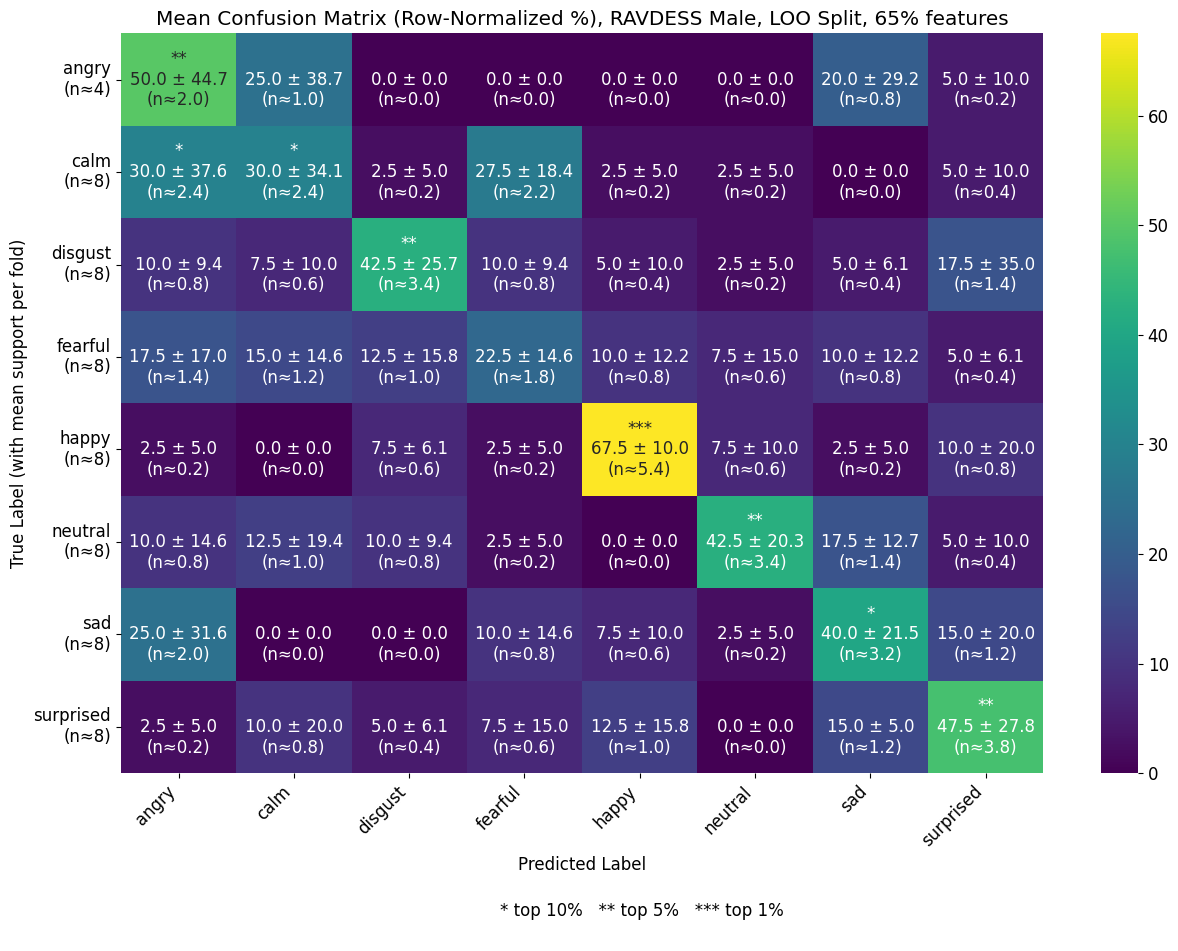

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({'font.size': 12})

conf_matrices_percent = conf_matrices / conf_matrices.sum(axis=2, keepdims=True) * 100

np.save('cm_ravdess_speaker_male.npy', conf_matrices_percent)

mean_cm = np.mean(conf_matrices_percent, axis=0)
std_cm = np.std(conf_matrices_percent, axis=0)

# Mean raw counts per fold
mean_counts = np.mean(conf_matrices, axis=0)

# Compute percentile thresholds for annotation
flat_vals = mean_cm.flatten()
thr_90 = np.percentile(flat_vals, 90)
thr_95 = np.percentile(flat_vals, 95)
thr_99 = np.percentile(flat_vals, 99)

# Create annotation labels with significance symbols + raw counts
labels = np.empty(mean_cm.shape, dtype=object)
for i in range(mean_cm.shape[0]):
    for j in range(mean_cm.shape[1]):
        val = mean_cm[i, j]
        symbol = ""
        if val >= thr_99:
            symbol = "***"
        elif val >= thr_95:
            symbol = "**"
        elif val >= thr_90:
            symbol = "*"
        labels[i, j] = f"{symbol}\n{val:.1f} ± {std_cm[i, j]:.1f}\n(n≈{mean_counts[i, j]:.1f})"

listik = ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']

# Per-class support (mean samples per true class per fold)
mean_support = np.mean(conf_matrices.sum(axis=2), axis=0)
row_labels = [f"{name}\n(n≈{sup:.0f})" for name, sup in zip(listik, mean_support)]

# Plot
plt.figure(figsize=(13, 9))
ax = sns.heatmap(mean_cm, annot=labels, fmt="", cmap="viridis", cbar=True)
ax.set_xticks(np.arange(len(listik)) + 0.5)
ax.set_yticks(np.arange(len(listik)) + 0.5)
ax.set_xticklabels(listik, rotation=45, ha="right")
ax.set_yticklabels(row_labels, rotation=0)
plt.title("Mean Confusion Matrix (Row-Normalized %), RAVDESS Male, LOO Split, 65% features")
plt.xlabel("Predicted Label")
plt.ylabel("True Label (with mean support per fold)")
plt.tight_layout()
plt.figtext(0.5, -0.05,
            "* top 10%   ** top 5%   *** top 1%\n",
            ha="center", fontsize=12)
plt.savefig("cm_ravdess_speaker_male.eps", bbox_inches='tight')
plt.show()